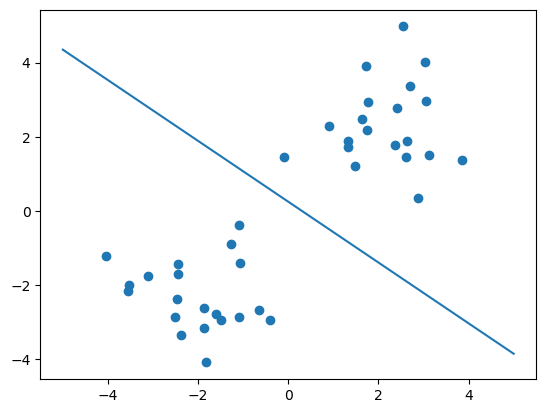

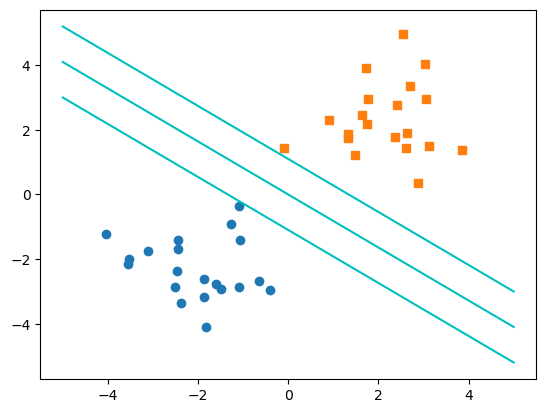

In [ ]:
from matplotlib import pyplot as plt
import numpy as np
import sympy as sp
import pandas as pd


data=np.array(pd.read_csv('/Users/liaoweihong/Desktop/Python/DAML/data4.csv', header=None))
y=data[:,0]; x=np.array(data[:,1:3]); sig2=10;
w1=sp.Symbol('w1'); w2=sp.Symbol('w2');
prior=sp.exp((-w1**2/sig2-w2**2/sig2)/2)/(2*np.pi*sig2)
post=prior;
for i in range(len(y)):
    post = post * (1/(1+sp.exp(-w1*x[i,0]-w2*x[i,1])))**(y[i]) * (sp.exp(-w1*x[i,0]-w2*x[i,1])/(1+sp.exp(-w1*x[i,0]-w2*x[i,1])))**(1-y[i]) 
post

# method 1
# w1v=np.linspace(0,2,101); w2v=np.linspace(0,2,101);
# postv=np.array([post.subs([(w1, w1v[i]), (w2, w2v[j])]) for i in range(len(w1v)) for j in range(len(w2v))])
# postv=np.array(postv);
# wv=np.array([[w1v[i], w2v[j]] for i in range(len(w1v)) for j in range(len(w2v))])
# wv[postv==max(postv)]

# method 2
# ans=sp.nsolve((sp.diff(post, w1), sp.diff(post, w2)), (w1,w2), (1.45,1.8))

ans=np.array([[1.63986317370797],[1.99984376304192]])
w1=ans[0,0]; w2=ans[1,0]
x1=sp.Symbol('x1'); x2=sp.Symbol('x2')
eq=sp.solve(w1*x1+w2*x2-0.5, x2)[0]
xx=np.linspace(-5,5,101)
yy=[eq.subs(x1, i) for i in xx]
plt.plot(xx, yy)
plt.scatter(x[:,0], x[:,1])
plt.show()

a=sp.Symbol('a')
eq=sp.solve(w1*x1+w2*x2-a, x2)[0]
xx=np.linspace(-5,5,101)
yy=[[eq.subs(x1, i).subs(a,j) for i in xx] for j in [-np.log(1/0.1-1), -np.log(1), -np.log(1/0.9-1)]]
for i in range(len(yy)):
    plt.plot(xx, yy[i],'c')
plt.scatter(x[y==0][:,0], x[y==0][:,1],marker='o')
plt.scatter(x[y==1][:,0], x[y==1][:,1],marker='s')
plt.show()